# Разведочный анализ данных (EDA)

**Проект:** Анализ международной мобильности российских студентов (2000–2024).

## Задачи

- Анализ общей динамики международной мобильности российских студентов.
- Анализ распределения потоков по регионам мира и странам.
- Оценка концентрации мобильности по странам.

## Данные

Для разведочного анализа используется очищенный на предыдущем этапе набор данных.

In [1]:
import pandas as pd

df=pd.read_csv('../data/processed/student_mobility_clean.csv')
df

,Страна,Год,Число студентов из РФ
0,Aruba,2003,0
1,Aruba,2006,0
2,Aruba,2009,0
3,Aruba,2010,0
4,Aruba,2011,0
...,...,...,...
1800,South Africa,2019,27
1801,South Africa,2020,20
1802,South Africa,2021,19
1803,South Africa,2022,13


## Динамика мобильности
Анализируется изменение общего числа российских студентов, обучавшихся за рубежом, в 2000-2024 гг.

In [2]:
students_by_year=df.groupby('Год')['Число студентов из РФ'].sum().reset_index()
students_by_year.to_csv('../data/processed/students_by_year.csv', index=False)

students_by_year.head()

,Год,Число студентов из РФ
0,2000,9287
1,2001,10947
2,2002,12672
3,2003,15950
4,2004,16042


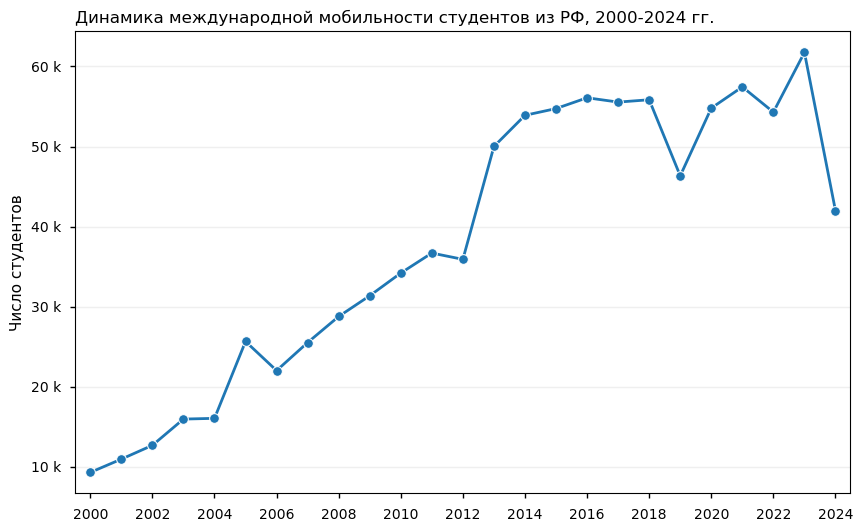

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import seaborn as sns

mpl.style.use('seaborn-v0_8-notebook')

plt.figure(figsize=(10,6))

ax=sns.lineplot(data=students_by_year, 
                  x='Год',
                  y='Число студентов из РФ',
                  marker='o',
                  linewidth=2)

ax.set_title('Динамика международной мобильности студентов из РФ, 2000-2024 гг.', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Число студентов')

ax.set_xticks(range(2000, 2025, 2))
ax.set_xticklabels(range(2000, 2025, 2), size=10)
ax.margins(x=0.02)

ax.grid(True, axis='y', alpha=0.2)

ax.yaxis.set_major_formatter(EngFormatter())

plt.savefig('../visuals/02_dynamics_2000_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## Структура мобильности

Анализируется распределение студентов по регионам мира, а также его изменение за 25 лет.  
Для добавления колонки "Регион" использовалась библиотека country_converter. Страны Америки ('America') дополнительно разделены на Северную ('North America') и Латинскую Америку ('Latin America').

In [4]:
import country_converter as coco

df['Регион']=coco.convert(df['Страна'],to='continent')
print(df.head())
print(df['Регион'].unique())

  Страна   Год  Число студентов из РФ   Регион
0  Aruba  2003                      0  America
1  Aruba  2006                      0  America
2  Aruba  2009                      0  America
3  Aruba  2010                      0  America
4  Aruba  2011                      0  America
['America' 'Europe' 'Asia' 'Oceania' 'Africa']


In [5]:
north_america_countries=['USA', 'United States', 'Canada']

def north_am(x):
    if x['Страна'] in north_america_countries:
        return 'North America'
    elif x['Регион']=='America':
        return 'Latin America'
    else:
        return x['Регион']
        
df['Регион']=df.apply(north_am, axis=1)
print(df.head())
print(df['Регион'].unique())

df.to_csv('../data/processed/student_mobility_clean_regions.csv', index=False)

  Страна   Год  Число студентов из РФ         Регион
0  Aruba  2003                      0  Latin America
1  Aruba  2006                      0  Latin America
2  Aruba  2009                      0  Latin America
3  Aruba  2010                      0  Latin America
4  Aruba  2011                      0  Latin America
['Latin America' 'Europe' 'Asia' 'Oceania' 'Africa' 'North America']


Рассчитаны число студентов по регионам мира и доли регионов в общей мобильности за весь период.

In [6]:
regions=df.groupby('Регион')['Число студентов из РФ'].sum().sort_values(ascending=False).reset_index()
regions['Доля региона, %']=(regions['Число студентов из РФ']/regions['Число студентов из РФ'].sum()*100).round(2)
regions.to_excel('../data/processed/regions.xlsx', index=False)
regions


,Регион,Число студентов из РФ,"Доля региона, %"
0,Europe,674972,71.22
1,Asia,175560,18.53
2,North America,71171,7.51
3,Oceania,21945,2.32
4,Latin America,2353,0.25
5,Africa,1685,0.18


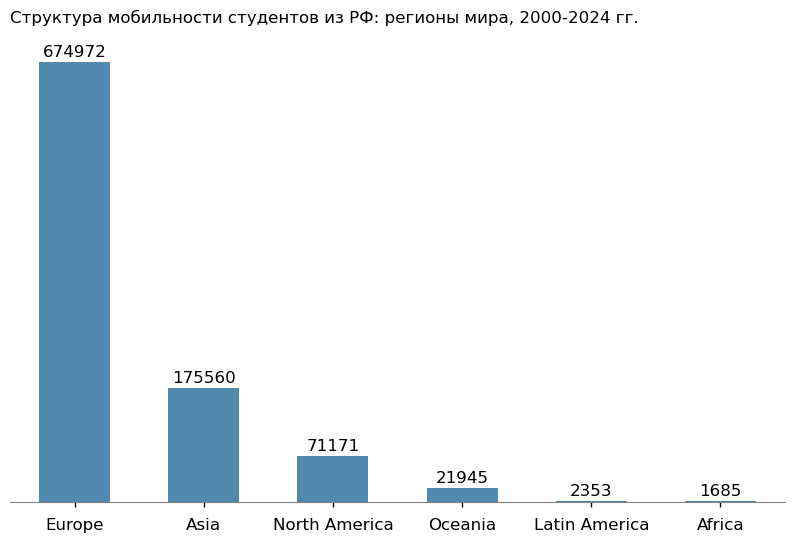

In [7]:
plt.figure(figsize=(10, 6))

ax=sns.barplot(data=regions,
                 x='Регион', 
                 y='Число студентов из РФ',
                alpha=0.85,
                width=0.55)

ax.set_title('Структура мобильности студентов из РФ: регионы мира, 2000-2024 гг.', loc='left', pad=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_xticks(regions['Регион'])
ax.set_xticklabels(regions['Регион'], fontsize=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('grey')

ax.bar_label(ax.containers[0], padding=2, fontsize=12)

plt.savefig('../visuals/02_regions.png', dpi=150, bbox_inches='tight')

plt.show()

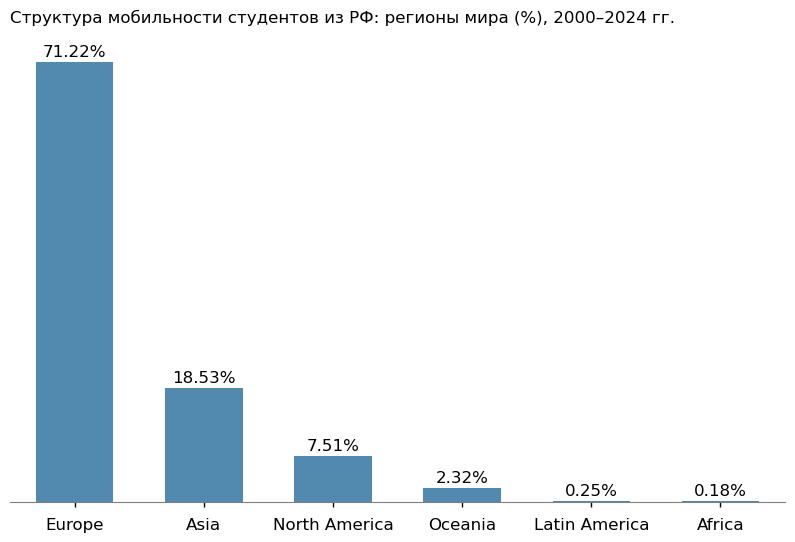

In [8]:
plt.figure(figsize=(10, 6))

ax=sns.barplot(
    data=regions,
    x='Регион',
    y='Доля региона, %',
    alpha=0.85,
    width=0.6)

ax.set_title('Структура мобильности студентов из РФ: регионы мира (%), 2000–2024 гг.', loc='left', pad=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_xticks(regions['Регион'])
ax.set_xticklabels(regions['Регион'], fontsize=12)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('grey')

ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=2, fontsize=12)

plt.savefig('../visuals/02_regions_share.png', dpi=150, bbox_inches='tight')
plt.show()

Для оценки динамики рассчитаны число студентов по регионами мира за каждый год и доли регионов.


In [17]:
regions_by_year=df.groupby(['Регион','Год'])['Число студентов из РФ'].sum().reset_index()

total_per_year=df.groupby('Год')['Число студентов из РФ'].sum().reset_index()
total_per_year.columns=['Год', 'Всего за год']

regions_by_year=regions_by_year.merge(total_per_year, on='Год')
regions_by_year['Доля региона, %']=(regions_by_year['Число студентов из РФ']/regions_by_year['Всего за год']*100).round(2)

regions_by_year=regions_by_year.drop(columns='Всего за год')

regions_by_year.to_csv('../data/processed/regions_by_year.csv', index=False)

regions_by_year


,Регион,Год,Число студентов из РФ,"Доля региона, %"
0,Africa,2000,0,0.00
1,Africa,2001,71,0.65
2,Africa,2002,0,0.00
3,Africa,2003,37,0.23
4,Africa,2004,40,0.25
...,...,...,...,...
144,Oceania,2020,859,1.57
145,Oceania,2021,629,1.09
146,Oceania,2022,576,1.06
147,Oceania,2023,795,1.29


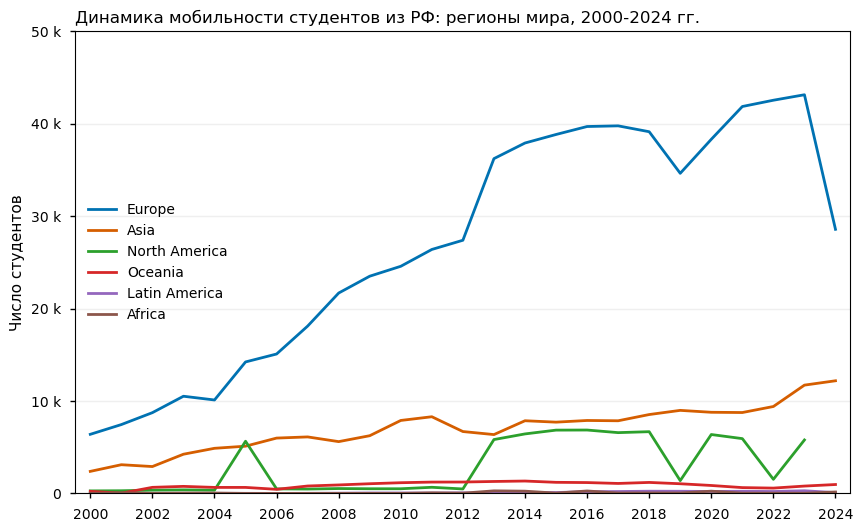

In [10]:
plt.figure(figsize=(10,6))

region_order=['Europe', 'Asia', 'North America', 'Oceania', 'Latin America', 'Africa']

custom_palette={'Europe':'#0072B2', 
                'Asia':'#D55E00', 
                'North America':sns.color_palette("tab10")[2], 
                'Oceania':sns.color_palette("tab10")[3], 
                'Latin America':sns.color_palette("tab10")[4], 
                'Africa':sns.color_palette("tab10")[5]}

ax=sns.lineplot(data=regions_by_year, 
                  x='Год',
                  y='Число студентов из РФ',
                  hue='Регион',
                  hue_order=region_order,
                  palette=custom_palette,
                  linewidth=2)

ax.set_title('Динамика мобильности студентов из РФ: регионы мира, 2000-2024 гг.', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Число студентов')

ax.set_xticks(range(2000, 2025, 2))
ax.set_xticklabels(range(2000, 2025, 2), size=10)
ax.set_ylim(0,50000)
ax.margins(x=0.02)

ax.legend(title=None,loc='center left',frameon=False)

ax.grid(True, axis='y', alpha=0.2)

ax.yaxis.set_major_formatter(EngFormatter())

plt.savefig('../visuals/02_regions_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()

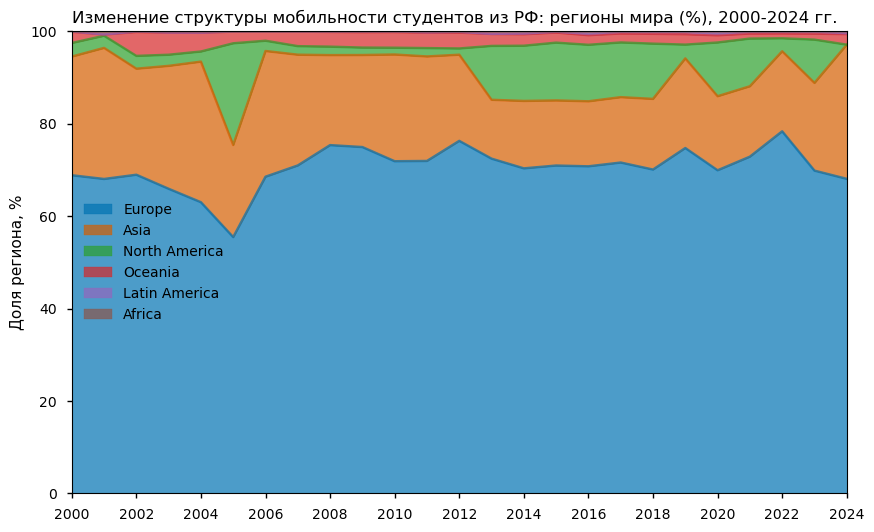

In [11]:
pivot_data=regions_by_year.pivot_table(
    index='Год',
    columns='Регион',
    values='Доля региона, %')

pivot_data=pivot_data[['Europe', 'Asia', 'North America', 'Oceania', 'Latin America', 'Africa']]

colors=['#0072B2', 
        '#D55E00', 
        sns.color_palette("tab10")[2], 
        sns.color_palette("tab10")[3], 
        sns.color_palette("tab10")[4], 
        sns.color_palette("tab10")[5]]

ax=pivot_data.plot.area(figsize=(10,6),alpha=0.7, color=colors)

ax.set_title('Изменение структуры мобильности студентов из РФ: регионы мира (%), 2000-2024 гг.', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Доля региона, %')

ax.set_xticks(range(2000, 2025, 2))
ax.set_xticklabels(range(2000, 2025, 2), size=10)

ax.legend(loc='center left',frameon=False)

ax.set_xlim(2000, 2024)
ax.set_ylim(0, 100)

plt.savefig('../visuals/02_regions_share_2000_2024.png', dpi=150, bbox_inches='tight')

plt.show()


## Концентрация потоков по странам

Выделены топ-10 стран по числу студентов из России, рассчитаны доли стран в общем потоке, кумулятивная доля и индекс Херфиндаля-Хиршмана (HHI) для оценки уровня концентрации мобильности по странам.

In [18]:
countries=df.groupby(['Страна','Регион'])['Число студентов из РФ'].sum().sort_values(ascending=False).reset_index()
countries['Доля страны, %']=(countries['Число студентов из РФ']/countries['Число студентов из РФ'].sum()*100).round(2)

countries.to_excel('../data/processed/countries.xlsx', index=False)

countries.head(10)



,Страна,Регион,Число студентов из РФ,"Доля страны, %"
0,Germany,Europe,123770,13.06
1,Czechia,Europe,79907,8.43
2,France,Europe,76612,8.08
3,United Kingdom,Europe,69804,7.37
4,United States,North America,49296,5.20
5,Ukraine,Europe,47199,4.98
6,Finland,Europe,42314,4.46
7,Kazakhstan,Asia,39012,4.12
8,Belarus,Europe,35264,3.72
9,Italy,Europe,33592,3.54


In [13]:
countries['Кумулятивная доля, %']=countries['Доля страны, %'].cumsum()
top_10=countries.head(10)

top_10.to_excel('../data/processed/top_10_countries.xlsx', index=False)

top_10

,Страна,Регион,Число студентов из РФ,"Доля страны, %","Кумулятивная доля, %"
0,Germany,Europe,123770,13.06,13.06
1,Czechia,Europe,79907,8.43,21.49
2,France,Europe,76612,8.08,29.57
3,United Kingdom,Europe,69804,7.37,36.94
4,United States,North America,49296,5.20,42.14
5,Ukraine,Europe,47199,4.98,47.12
6,Finland,Europe,42314,4.46,51.58
7,Kazakhstan,Asia,39012,4.12,55.70
8,Belarus,Europe,35264,3.72,59.42
9,Italy,Europe,33592,3.54,62.96


In [14]:
countries['Страна'].nunique()

110

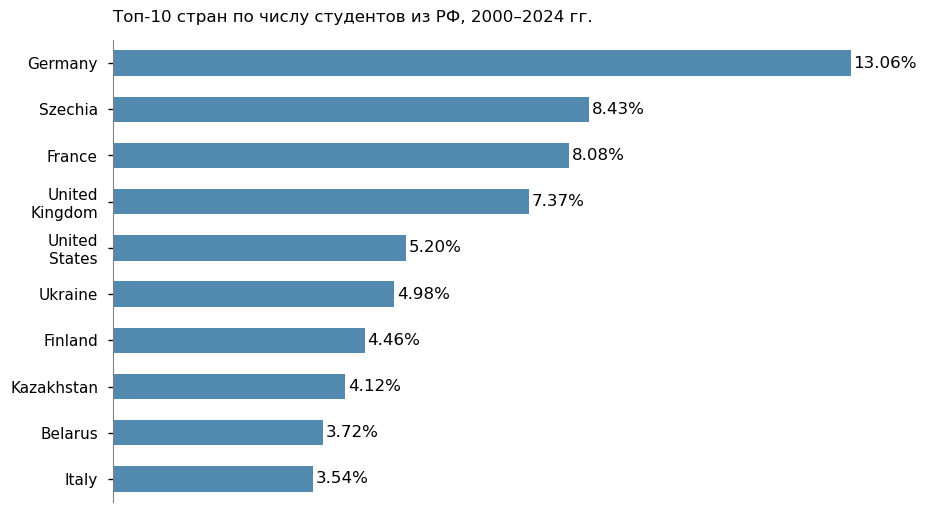

In [15]:
plt.figure(figsize=(10, 6))

ax=sns.barplot(
    data=top_10,
    y='Страна',
    x='Доля страны, %',
    alpha=0.85,
    width=0.55)

ax.set_title('Топ-10 стран по числу студентов из РФ, 2000–2024 гг.', loc='left', pad=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_color('grey')

ax.set_yticks(range(len(top_10['Страна'])))
ax.set_yticklabels(labels=['Germany', 'Szechia', 'France', 
                           'United\nKingdom', 'United\nStates', 
                           'Ukraine', 'Finland', 'Kazakhstan', 
                           'Belarus', 'Italy'], fontsize=11)

ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=2, fontsize=12)

plt.savefig('../visuals/02_overall_top_10.png', dpi=150, bbox_inches='tight')

plt.show()

In [16]:
hhi=((countries['Доля страны, %'] / 100)**2).sum()
hhi

np.float64(0.053419570000000006)

## Основные результаты

За период с 2000 по 2024 г. общее число российских студентов за рубежом выросло в 4,5 раза (оценка может быть занижена из-за неполноты данных по странам), составив почти 42 000 человек в 2024 г. Всего за границей обучалось 947 686 студентов в 110 странах. Абсолютным лидером по числу студентов из России является Германия, ее доля в общем потоке составляет 13%.

Для международной мобильности российских студентов характерны следующие особенности:
- рост общего числа студентов до 2018 г. с последующей повышенной изменчивостью динамики и снижением мобильности с 2023 г.;
- устойчивая региональная структура с доминированием европейских направлений (71% от общей мобильности) и ограниченной диверсификацией;
- умеренная концентрация мобильности (HHI=0,053) с распределением основной части потока между странами-лидерами (CR5=42%, CR10=63%) и сохранением широкой географии направлений.